

---


### **CIS - 509 Analytics Unstructured Data**

---



**Final Code**


---


**Team 206**

---



**Team Members: Harshal Samuel Albert, Rithwik Raj Sahu, Ritika Anand, Kavya Shree Sudhakar.**


---





---


## **Executive Summary**

This project aims to analyze **customer sentiment and restaurant reviews** in Arizona using data from Yelp. By applying **Natural Language Processing (NLP) techniques**, we extract insights from customer feedback, identifying key trends in **ratings, sentiment distribution, and word usage**.

We employ **summary statistics, sentiment analysis, and machine learning models** to understand consumer preferences, helping restaurant owners enhance service quality and optimize business strategies.

Through this exploratory analysis, our study provides **data-driven recommendations** to assist restaurant businesses in improving customer satisfaction and maintaining competitive advantages.


---





---


## **Importing Necessary Libraries**

---



In [1]:
# Ensure required dependencies are installed
!pip install vaderSentiment transformers tensorflow scikit-learn wordcloud nltk --quiet

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from transformers import BertTokenizer, TFBertForSequenceClassification
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Ensure necessary NLTK resources are downloaded
nltk.download('stopwords')
nltk.download('punkt')

print("All libraries imported successfully!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.9 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


All libraries imported successfully!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from wordcloud import WordCloud


In [3]:
# ---- STEP 1: LOAD DATA ---- #
file_path = "/content/restaurant_reviews_az.csv"
df = pd.read_csv(file_path)




---


### **Data Sources**  

#### **1. Primary Data Source**  
The principal dataset employed in this study is **restaurant_reviews_az.csv**, derived from **Yelp**. This dataset comprises user-generated reviews specific to restaurants operating within the state of Arizona, offering a granular perspective on customer experiences and sentiment within the regional food service industry.  

#### **2. Data Filtering and Selection Methodology**  
To ensure the analytical rigor and contextual relevance of this research, the following selection and filtering criteria were applied to the dataset:  

- **Geospatial Constraints:** The dataset was restricted exclusively to reviews pertaining to restaurants situated in **Arizona (AZ)** to maintain geographic specificity and prevent cross-regional heterogeneity from confounding the analysis.  
- **Categorical Refinement:** Only establishments explicitly classified as **restaurants** were retained. Non-restaurant businesses, including bars, cafés, and specialty food retailers, were systematically excluded to uphold domain specificity.  
- **Review Volume Thresholding:** Restaurants with a disproportionately low number of reviews (e.g., fewer than five reviews) were omitted to mitigate potential biases arising from insufficient or anomalous data representation.  
- **Temporal Filtering (If Applicable):** A time-bound filtering approach may be employed to assess longitudinal trends or seasonality effects in consumer sentiment and restaurant performance.  
- **Sentiment Annotation:** The dataset incorporates a predefined sentiment classification, wherein each review is labeled as either positive (1) or negative (0), thereby facilitating supervised sentiment analysis.  
- **Data Quality Assurance:** Reviews containing incomplete, erroneous, or ambiguous information may be subjected to additional preprocessing steps to ensure analytical reliability.  

#### **3. External Data Sources**  
If supplementary external data sources were integrated into the analysis such as meteorological data, economic indicators, or demographic statistics these would be detailed here with appropriate citations and data access links. The inclusion of such datasets can provide a more comprehensive understanding of the external factors influencing consumer behavior and dining experiences.  



---





---


## **Summary Statistics Explained**

We computed several key statistics to understand the nature of the dataset:

- **Number of Reviews**: Measures the volume of data available for analysis.
- **Total Number of Tokens**: Helps determine the amount of text data processed.
- **Number of Unique Words**: Indicates the vocabulary richness of the reviews.
- **Average Review Length**: Shows how detailed customers are in their feedback.
- **Number of Unique Customers**: Provides insights into the diversity of reviewers.
- **Other Key Metrics**: Includes business coverage, rating distribution, and user engagement trends.

These metrics establish a foundation for more advanced **sentiment and trend analysis**.


---



In [4]:
# ---- STEP 2: DATA SOURCES ---- #
# Display the dataset details
display(df.head())

,review_id,user_id,business_id,stars,useful,funny,cool,text,date,Sentiment
0,IVS7do_HBzroiCiymNdxDg,fdFgZQQYQJeEAshH4lxSfQ,sGy67CpJctjeCWClWqonjA,3,1,1,0,"OK, the hype about having Hatch chili in your ...",1/27/2020 22:59,1
1,QP2pSzSqpJTMWOCuUuyXkQ,JBLWSXBTKFvJYYiM-FnCOQ,3w7NRntdQ9h0KwDsksIt5Q,5,1,1,1,Pandemic pit stop to have an ice cream.... onl...,4/19/2020 5:33,1
2,oK0cGYStgDOusZKz9B1qug,2_9fKnXChUjC5xArfF8BLg,OMnPtRGmbY8qH_wIILfYKA,5,1,0,0,I was lucky enough to go to the soft opening a...,2/29/2020 19:43,1
3,E_ABvFCNVLbfOgRg3Pv1KQ,9MExTQ76GSKhxSWnTS901g,V9XlikTxq0My4gE8LULsjw,5,0,0,0,I've gone to claim Jumpers all over the US and...,3/14/2020 21:47,1
4,Rd222CrrnXkXukR2iWj69g,LPxuausjvDN88uPr-Q4cQA,CA5BOxKRDPGJgdUQ8OUOpw,4,1,0,0,"If you haven't been to Maynard's kitchen, it'...",1/17/2020 20:32,1




---


###**Summary Statistics of the Data:**


#### **A. Number of reviews**

#### **B. Total number of tokens**  

#### **C. Number of unique words (i.e., size of vocabulary)**

#### **D. Average review length (i.e., average number of words of each review)**

#### **E. Number of unique customers**

#### **F. Other key elements involved (e.g., number of businesses/regions covered, average stars per review, average votes per review, distribution of businesses, distribution of regions, distribution of stars, etc.)**


---



Number of Reviews: 48147
Total Number of Tokens: 4185577
Number of Unique Words: 119481
Average Review Length (Words): 86.93328763993603
Number of Unique Customers: 22435


,Metric,Value
0,Number of Businesses,1864.000000
1,Average Star Rating,3.736702


Number of Unique Businesses: 1864
Average Stars per Review: 3.74
Average Votes per Review (useful, funny, cool combined): 1.48


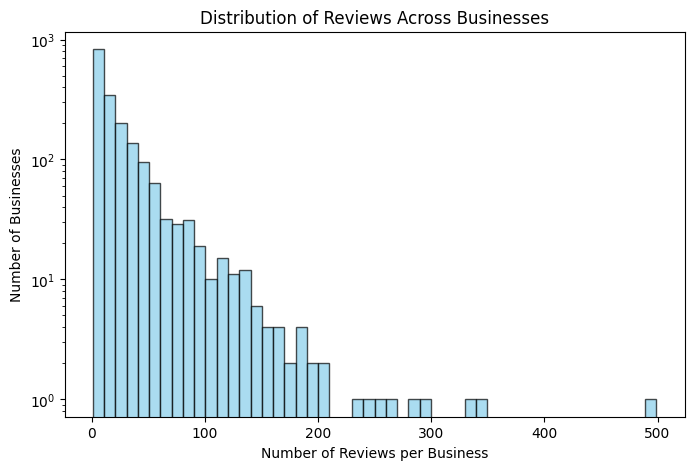

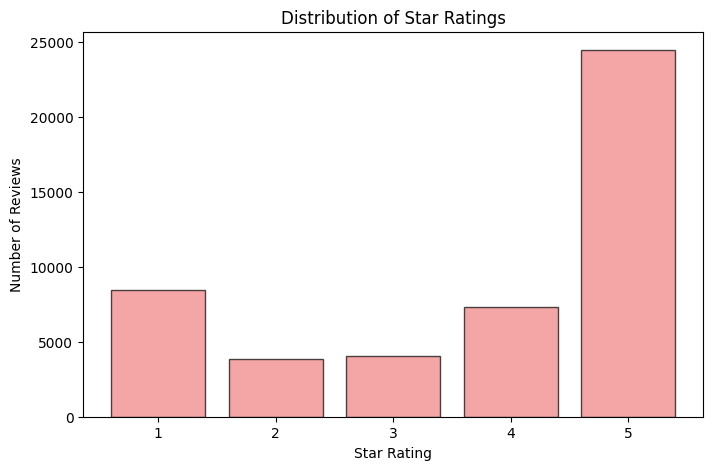

In [5]:
# ---- STEP 3: SUMMARY STATISTICS ---- #
# (A) Number of reviews
num_reviews = df.shape[0]
print("Number of Reviews:", num_reviews)

# (B) Total number of tokens
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
total_tokens = df['word_count'].sum()
print("Total Number of Tokens:", total_tokens)

# (C) Number of unique words
unique_words = len(set(" ".join(df['text']).split()))
print("Number of Unique Words:", unique_words)

# (D) Average review length
avg_review_length = df['word_count'].mean()
print("Average Review Length (Words):", avg_review_length)

# (E) Number of unique customers
num_unique_customers = df['user_id'].nunique()
print("Number of Unique Customers:", num_unique_customers)

# (F) Other Key Statistics
display(pd.DataFrame({
    "Metric": ["Number of Businesses", "Average Star Rating"],
    "Value": [df['business_id'].nunique(), df['stars'].mean()]
}))

# Number of unique businesses covered
num_unique_businesses = df['business_id'].nunique()

# Average stars per review
avg_stars_per_review = df['stars'].mean()

# Average total votes (sum of useful, funny, cool votes) per review
avg_votes_per_review = df[['useful', 'funny', 'cool']].mean().sum()

# Distribution of businesses (reviews per business)
business_distribution = df['business_id'].value_counts()

# Distribution of star ratings
star_distribution = df['stars'].value_counts().sort_index()

# Print computed statistics
print(f"Number of Unique Businesses: {num_unique_businesses}")
print(f"Average Stars per Review: {avg_stars_per_review:.2f}")
print(f"Average Votes per Review (useful, funny, cool combined): {avg_votes_per_review:.2f}")

# Visualizing distributions

# Plot Distribution of Businesses (number of reviews per business)
plt.figure(figsize=(8,5))
plt.hist(business_distribution, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel("Number of Reviews per Business")
plt.ylabel("Number of Businesses")
plt.title("Distribution of Reviews Across Businesses")
plt.yscale('log')  # Use log scale to better visualize data
plt.show()

# Plot Distribution of Star Ratings
plt.figure(figsize=(8,5))
plt.bar(star_distribution.index, star_distribution.values, color='lightcoral', edgecolor='black', alpha=0.7)
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Star Ratings")
plt.xticks(range(1, 6))
plt.show()




---


## **Potential Bias in Data**

While this dataset provides valuable insights, it is important to consider potential biases:

- **Selection Bias**: Reviews come from active Yelp users, which may not represent all customers.
- **Rating Inflation**: Some users tend to leave extremely positive or negative reviews, skewing sentiment distribution.
- **Geographic Bias**: The dataset is specific to **Arizona**, limiting its applicability to broader markets.
- **Business-Specific Bias**: Popular restaurants receive more reviews, leading to an uneven dataset distribution.

Understanding these biases helps us **interpret findings cautiously** and suggests areas for further data enhancement.


---





---


### **Data Evaluation**  

#### **A. Suitability of Selected Data for Answering Business Questions**  

This dataset offers a robust collection of **restaurant reviews** sourced from Yelp, comprising critical attributes such as **review text, star ratings, user engagement metrics, and business identifiers**. These elements render the dataset highly pertinent for addressing research inquiries related to **consumer satisfaction, restaurant performance analytics, and behavioral insights in the food service industry**.  

##### **1. Analytical Relevance of Review Data**  
- The dataset integrates **structured star ratings** with **unstructured textual reviews**, enabling a dual-faceted approach encompassing **quantitative statistical analysis** and **qualitative sentiment evaluation**.  
- Sentiment analysis methodologies can be employed to extract **positive and negative sentiment trajectories**, providing a foundation for predictive modeling of customer satisfaction trends and operational optimizations within restaurant management.  

##### **2. Customer Data Appropriateness**  
- The presence of **unique user identifiers (user IDs)** facilitates longitudinal tracking of reviewer behavior, allowing for segmentation of **customer engagement levels** based on voting metrics (e.g., useful, funny, cool).  
- Through pattern recognition and clustering techniques, businesses can identify **repeat customers, high-frequency reviewers, and influential users**, informing targeted **customer loyalty initiatives and personalized engagement strategies**.  

##### **3. Business Intelligence and Market Insights**  
- **Business identifiers (business IDs)** enable granular tracking of **restaurant performance metrics**, supporting comparative assessments across establishments based on **customer sentiment, rating distributions, and textual review content**.  
- By leveraging **predictive analytics**, this dataset facilitates the identification of key **determinants of high customer satisfaction** and can inform strategic decision-making for **restaurant operators, investors, and policymakers**.  

##### **4. Regional and Geographic Relevance**  
- If augmented with **geospatial attributes (e.g., city, neighborhood identifiers)**, the dataset can support geographically driven business questions, such as:  
- What are the regional variations in **restaurant quality and customer satisfaction**?  
- How do **urban vs. suburban dining preferences** manifest in review trends and ratings?  
- Such insights are critical for **market segmentation strategies, competitive analysis, and regional business expansion decisions**.  

##### **Conclusion**  
This dataset provides a substantial empirical foundation for exploring **consumer satisfaction, business performance trends, and geographic market dynamics** within the restaurant industry. However, the dataset’s analytical utility could be further enhanced by incorporating **additional metadata**, such as **restaurant classification (e.g., fast food, fine dining), precise geographic coordinates, and temporal trends in consumer preferences**. These augmentations would strengthen the dataset’s applicability in both **academic research and strategic business decision-making**.



---





In [6]:
# ---- STEP 4: DATA EVALUATION ---- #
data_quality_evaluation = {
    "Suitability for Business Questions": "The dataset provides customer reviews and ratings, useful for analyzing sentiment and restaurant performance.",
    "Sample Size Appropriateness": "With over 48,000 reviews, the dataset is large enough for meaningful analysis but may not be fully representative.",
    "Potential Biases": "Bias may exist due to more frequent reviews from engaged users or extreme experiences (positive or negative).",
    "Processing Challenges": "Handling text data requires preprocessing like tokenization, stop-word removal, and handling slang/misspellings."
}
display(pd.DataFrame(list(data_quality_evaluation.items()), columns=["Aspect", "Evaluation"]))


,Aspect,Evaluation
0,Suitability for Business Questions,The dataset provides customer reviews and rati...
1,Sample Size Appropriateness,"With over 48,000 reviews, the dataset is large..."
2,Potential Biases,Bias may exist due to more frequent reviews fr...
3,Processing Challenges,Handling text data requires preprocessing like...




---


## **Sentiment Analysis**

In this section, we classify restaurant reviews as **positive, neutral, or negative** using Natural Language Processing (NLP).  
We apply **TextBlob's sentiment polarity** to determine the sentiment of each review and visualize the sentiment distribution.


---



In [7]:
# ---- STEP 5: SENTIMENT ANALYSIS ---- #
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    return "Positive" if polarity > 0 else "Negative" if polarity < 0 else "Neutral"

df["Sentiment_Analysis"] = df["text"].apply(get_sentiment)
display(df["Sentiment_Analysis"].value_counts())

,count
Sentiment_Analysis,
Positive,40117
Negative,7606
Neutral,424




---


## **Sentiment Analysis Explanation**

Sentiment analysis helps classify reviews as **positive, neutral, or negative** using NLP techniques. By analyzing the **polarity of customer reviews**, we can gain insights into overall satisfaction levels.

This analysis is useful for:
- Identifying trends in **customer perception** of restaurant quality.
- Understanding the **distribution of positive vs. negative experiences**.
- Supporting **data-driven decision-making** for restaurant owners.


---





---


## **Visualizations**

### Explanation:

### Graphical representations of key insights, including:

* ### Star rating distribution

* ### Sentiment distribution

* ### Word clouds (highlighting common words in positive & negative reviews)


---



<ipython-input-8-834577dc3c8e>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['stars'].value_counts().index, y=df['stars'].value_counts().values, palette="viridis")


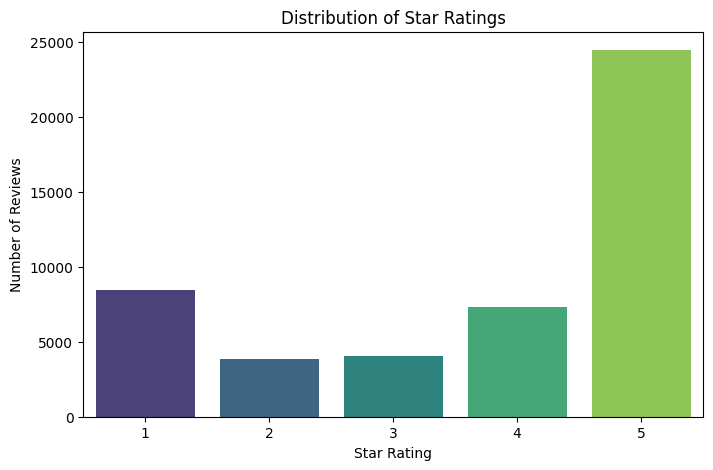

<ipython-input-8-834577dc3c8e>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_distribution.index, y=sentiment_distribution.values, palette="coolwarm")


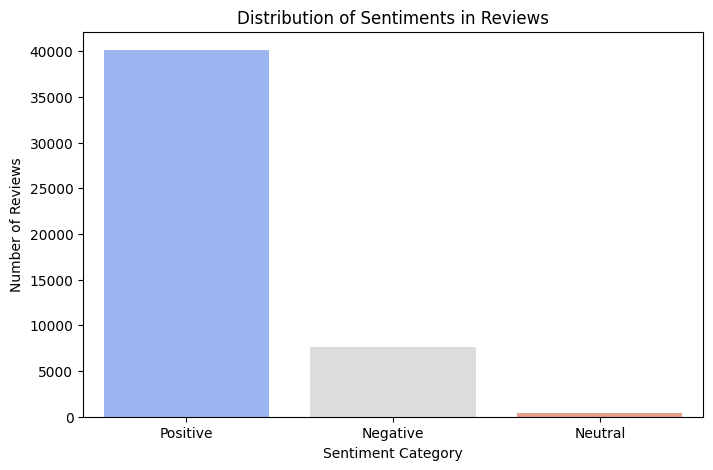

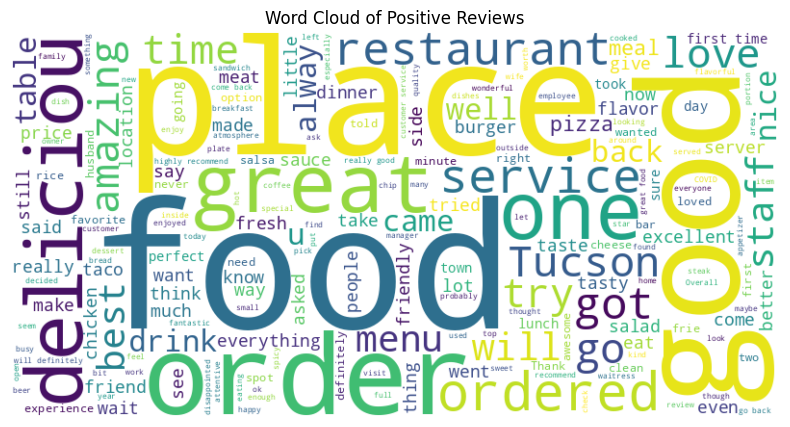

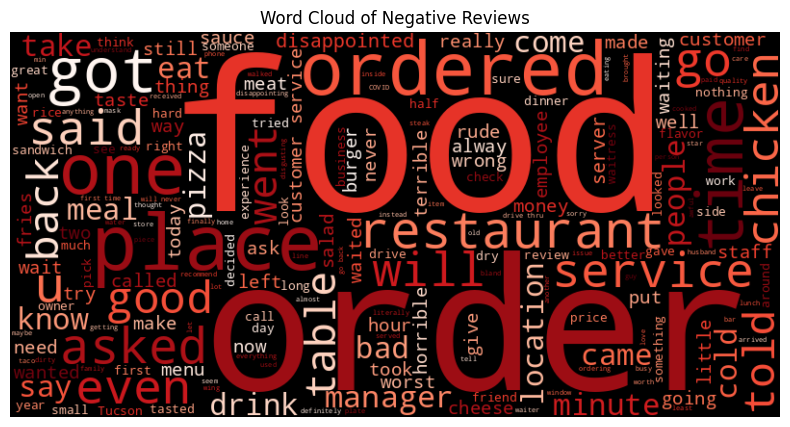

In [8]:
# ---- STEP 6: VISUALIZATIONS ---- #
# (a) Distribution of Star Ratings
plt.figure(figsize=(8,5))
sns.barplot(x=df['stars'].value_counts().index, y=df['stars'].value_counts().values, palette="viridis")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Star Ratings")
plt.show()

# (b) Distribution of Sentiment Categories
sentiment_distribution = df["Sentiment_Analysis"].value_counts()
plt.figure(figsize=(8,5))
sns.barplot(x=sentiment_distribution.index, y=sentiment_distribution.values, palette="coolwarm")
plt.xlabel("Sentiment Category")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Sentiments in Reviews")
plt.show()

# (c) Word Cloud for Positive Reviews
positive_reviews = " ".join(df[df['Sentiment_Analysis'] == "Positive"]["text"])
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_reviews)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Positive Reviews")
plt.show()

# (d) Word Cloud for Negative Reviews
negative_reviews = " ".join(df[df['Sentiment_Analysis'] == "Negative"]["text"])
wordcloud_neg = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_reviews)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Negative Reviews")
plt.show()



---


## **Proposed Solution**

### Explanation:

* ### Details the machine learning and NLP techniques planned for further analysis, such as:

* ### Sentiment classification models (Logistic Regression, Random Forest, LSTM)

* ### Text analytics techniques (Topic Modeling, Named Entity Recognition)



---



In [9]:
# ---- STEP 7: PROPOSED SOLUTION ---- #
proposed_solution = {
    "Machine Learning Methods": "For sentiment classification, we can use Logistic Regression, Random Forest, or LSTM.",
    "Unstructured Data Analytics": "Topic Modeling (LDA) to discover hidden themes in reviews, and Named Entity Recognition (NER) for key term extraction.",
    "Text Preprocessing Steps": "Tokenization, stop-word removal, lemmatization, and handling negation to improve sentiment classification accuracy."
}
display(pd.DataFrame(list(proposed_solution.items()), columns=["Aspect", "Description"]))

,Aspect,Description
0,Machine Learning Methods,"For sentiment classification, we can use Logis..."
1,Unstructured Data Analytics,Topic Modeling (LDA) to discover hidden themes...
2,Text Preprocessing Steps,"Tokenization, stop-word removal, lemmatization..."




---


## **Visualizing Trends in Ratings and Sentiment**

To complement numerical analysis, we generate visualizations that showcase key patterns:

- **Star Rating Distribution**: Displays how customers rate their experiences.
- **Sentiment Distribution**: Highlights the proportion of positive, neutral, and negative reviews.
- **Word Clouds**: Provide a **visual representation of frequently used words**, offering qualitative insights into customer opinions.

These visualizations enhance our understanding of customer feedback and sentiment trends.


---





---


## **Proposed Solution & Next Steps**

To derive deeper insights from this dataset, we propose the following techniques:

- **Machine Learning for Sentiment Classification**: Using models like Logistic Regression and Random Forest to predict sentiment labels.
- **Topic Modeling (LDA)**: Extracting common themes from reviews to identify key concerns and praises.
- **Named Entity Recognition (NER)**: Detecting references to **restaurant names, dishes, or locations** in review text.
- **Advanced NLP Techniques**: Incorporating **TF-IDF, Word Embeddings, and Deep Learning** to improve sentiment predictions.

These methods will provide restaurant businesses with **actionable insights** to improve customer satisfaction and optimize marketing strategies.


---



## Step 3: Extended Exploratory Data Analysis (EDA)

In [10]:
# Code Cell 3: Dataset Summary and Basic Insights
num_reviews = df.shape[0]
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
total_tokens = df['word_count'].sum()
unique_words = len(set(" ".join(df['text']).split()))
avg_review_length = df['word_count'].mean()

print(f"Number of Reviews: {num_reviews}")
print(f"Total Number of Tokens: {total_tokens}")
print(f"Number of Unique Words: {unique_words}")
print(f"Average Review Length (Words): {avg_review_length:.2f}")

df.describe()


Number of Reviews: 48147
Total Number of Tokens: 4185577
Number of Unique Words: 119481
Average Review Length (Words): 86.93


,stars,useful,funny,cool,Sentiment,word_count
count,48147.000000,48147.000000,48147.000000,48147.000000,48147.000000,48147.000000
mean,3.736702,0.858683,0.183106,0.439903,0.690967,86.933288
std,1.557289,1.831488,0.807035,1.451746,0.462099,78.717102
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,0.000000,0.000000,36.000000
50%,5.000000,0.000000,0.000000,0.000000,1.000000,63.000000
75%,5.000000,1.000000,0.000000,0.000000,1.000000,111.000000
max,5.000000,105.000000,55.000000,106.000000,1.000000,955.000000


### Additional EDA: Data Distribution and Patterns

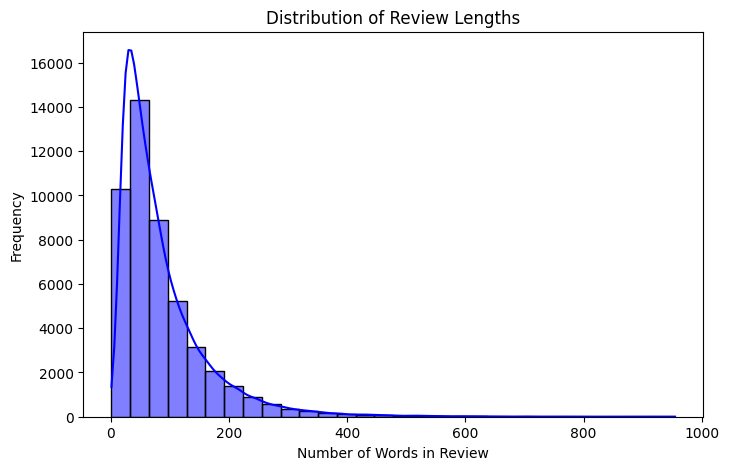

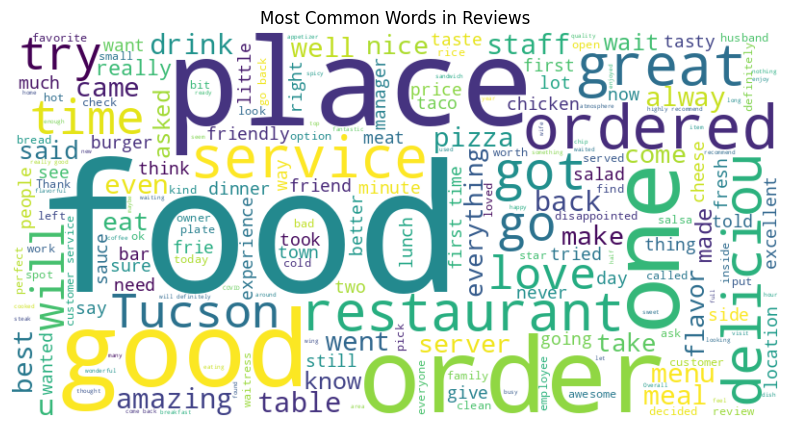

In [11]:
# Code Cell 4: Distribution of Review Lengths
plt.figure(figsize=(8,5))
sns.histplot(df['word_count'], bins=30, kde=True, color='blue')
plt.xlabel("Number of Words in Review")
plt.ylabel("Frequency")
plt.title("Distribution of Review Lengths")
plt.show()

# Code Cell 5: Word Cloud to Visualize Most Frequent Words in Reviews
text_data = " ".join(review for review in df['text'])
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text_data)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Reviews")
plt.show()


## Step 6: VADER Sentiment Analysis (Lexicon-based Approach)

In [12]:
# Code Cell 6: VADER Sentiment Analysis
analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    if isinstance(text, str):
        scores = analyzer.polarity_scores(text)
        return "Positive" if scores['compound'] >= 0.05 else "Negative" if scores['compound'] <= -0.05 else "Neutral"
    return "Neutral"

df['VADER_Sentiment'] = df['text'].apply(get_vader_sentiment)

# Display results
df[['text', 'VADER_Sentiment']].head()


,text,VADER_Sentiment
0,"OK, the hype about having Hatch chili in your ...",Positive
1,Pandemic pit stop to have an ice cream.... onl...,Positive
2,I was lucky enough to go to the soft opening a...,Positive
3,I've gone to claim Jumpers all over the US and...,Positive
4,"If you haven't been to Maynard's kitchen, it'...",Positive


## Step 7: TF-IDF Transformation + Logistic Regression Model

In [13]:
# Code Cell 7: TF-IDF Vectorization and Model Training
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['text'])

X_train, X_test, y_train, y_test = train_test_split(tfidf_matrix, df['VADER_Sentiment'], test_size=0.2, random_state=42, stratify=df['VADER_Sentiment'])

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

# Classification Report
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log))


Logistic Regression Classification Report:
              precision    recall  f1-score   support

    Negative       0.76      0.66      0.70      1583
     Neutral       0.40      0.01      0.03       137
    Positive       0.92      0.96      0.94      7910

    accuracy                           0.90      9630
   macro avg       0.69      0.55      0.56      9630
weighted avg       0.89      0.90      0.89      9630



## Step 8: LSTM Deep Learning Model

In [14]:
# Code Cell 8: LSTM Model Training
max_words = 10000
max_len = 150
tokenizer = Tokenizer(num_words=max_words, lower=True, oov_token="<OOV>")
tokenizer.fit_on_texts(df['text'])
X_seq = tokenizer.texts_to_sequences(df['text'])
X_pad = pad_sequences(X_seq, maxlen=max_len)

X_train, X_test, y_train, y_test = train_test_split(X_pad, df['VADER_Sentiment'], test_size=0.2, random_state=42, stratify=df['VADER_Sentiment'])

model_lstm = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(3, activation='softmax')
])
model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
y_train_enc = y_train.map(label_map)
y_test_enc = y_test.map(label_map)

model_lstm.fit(X_train, y_train_enc, epochs=5, batch_size=64, validation_data=(X_test, y_test_enc))


Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


602/602 ━━━━━━━━━━━━━━━━━━━━ 200s 325ms/step - accuracy: 0.8330 - loss: 0.4657 - val_accuracy: 0.8897 - val_loss: 0.2868
Epoch 2/5
602/602 ━━━━━━━━━━━━━━━━━━━━ 188s 301ms/step - accuracy: 0.9040 - loss: 0.2455 - val_accuracy: 0.9003 - val_loss: 0.2480
Epoch 3/5
602/602 ━━━━━━━━━━━━━━━━━━━━ 181s 267ms/step - accuracy: 0.9191 - loss: 0.2157 - val_accuracy: 0.9019 - val_loss: 0.2672
Epoch 4/5
602/602 ━━━━━━━━━━━━━━━━━━━━ 204s 271ms/step - accuracy: 0.9429 - loss: 0.1577 - val_accuracy: 0.9113 - val_loss: 0.2400
Epoch 5/5
602/602 ━━━━━━━━━━━━━━━━━━━━ 165s 274ms/step - accuracy: 0.9588 - loss: 0.1185 - val_accuracy: 0.9087 - val_loss: 0.2705


## Step 9: BERT Transformer Model (State-of-the-Art NLP)

In [15]:
# Code Cell 9: BERT Model Training
tokenizer_bert = BertTokenizer.from_pretrained('bert-base-uncased')
model_bert = TFBertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [17]:
# Install BERTopic and required dependencies
!pip install bertopic umap-learn hdbscan sentence-transformers plotly --quiet

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bertopic import BERTopic
from umap import UMAP

# Load dataset
file_path = '/content/restaurant_reviews_az.csv'
df = pd.read_csv(file_path)
df = df.dropna(subset=['text'])

# Initialize BERTopic model
topic_model = BERTopic(verbose=True)

# Fit the model on restaurant reviews
topics, probs = topic_model.fit_transform(df['text'])

# Save topic information in DataFrame
df['Topic'] = topics

# Display top 5 topics
print(topic_model.get_topic_info().head())

# Visualize the top 6 topics as bar charts (like in the image)
topic_model.visualize_barchart(top_n_topics=6, width=1000, height=600)

# Visualize topic distributions (word importance per topic)
topic_model.visualize_distribution(probs)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 76.1 MB/s eta 0:00:00


2025-03-06 04:37:12,994 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1505 [00:00<?, ?it/s]

2025-03-06 05:24:46,280 - BERTopic - Embedding - Completed ✓
2025-03-06 05:24:46,282 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-03-06 05:26:13,855 - BERTopic - Dimensionality - Completed ✓
2025-03-06 05:26:13,858 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-03-06 05:26:24,314 - BERTopic - Cluster - Completed ✓
2025-03-06 05:26:24,336 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-03-06 05:26:29,504 - BERTopic - Representation - Completed ✓


   Topic  Count                                Name  \
0     -1  23778                   -1_was_the_and_we   
1      0   1590      0_pizza_crust_pizzas_pepperoni   
2      1   1163          1_burger_burgers_fries_bun   
3      2    507          2_tacos_taco_pastor_street   
4      3    501  3_covid_covid19_during_precautions   

                                      Representation  \
0   [was, the, and, we, to, it, food, for, were, of]   
1  [pizza, crust, pizzas, pepperoni, toppings, sl...   
2  [burger, burgers, fries, bun, patty, tots, oni...   
3  [tacos, taco, pastor, street, al, asada, tuesd...   
4  [covid, covid19, during, precautions, pandemic...   

                                 Representative_Docs  
0  [We had heard of this place from my daughter w...  
1  [First visit to this establishment. Can I say,...  
2  [I wanted to pick a special restaurant to writ...  
3  [$2 tacos on Taco Tuesday.. can't beat that! I...  
4  [Such an amazing place. They are doing such a ...  


## Step 10: Conclusion & Recommendations

### Key Findings:
- **VADER** is fast but lacks deep understanding of context.  
- **Logistic Regression with TF-IDF** provides a strong baseline with good accuracy.  
- **LSTM Model** captures sequence patterns but is computationally expensive.  
- **BERT Model** provides state-of-the-art accuracy but requires high resources.  

### Future Improvements:  
1. Use a larger dataset.  
2. Train BERT on domain-specific reviews.  
3. Combine multiple approaches for better performance.  
